# L5. Teaching It to See

The device learns a new object by writing example vectors to memory: no retraining, no fine-tuning. Bring photos of something you own and teach it yourself. Then everything you built lands in one assistant that answers questions and recognizes what you taught it, offline, with one last cell that sends memory to the cloud only when you say so.

## 1. The object you'll teach

In [1]:
from helper import object_photos

# Teach the device one object you own. Paste image URLs of it: two or
# more from different angles to teach, and one more to test. Leave these
# empty to run on the bundled example.
MY_LABEL = "orange flower"
TEACH_URLS = []
TEST_URL = ""

teach_photos, test_photo = object_photos(TEACH_URLS, TEST_URL)

## 2. An object-memory shard

In [2]:
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
    Point, UpdateOperation, Query, QueryRequest,
)
from helper import embed_image, fresh_start

OBJECT_DIR = fresh_start("./object_shard")

config = EdgeConfig(
    vectors={
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
object_shard = EdgeShard.create(OBJECT_DIR, config)
RECOGNIZE_THRESHOLD = 0.80
print("Object shard ready. threshold =", RECOGNIZE_THRESHOLD)

Object shard ready. threshold = 0.8


## 3. Teach what it already knows

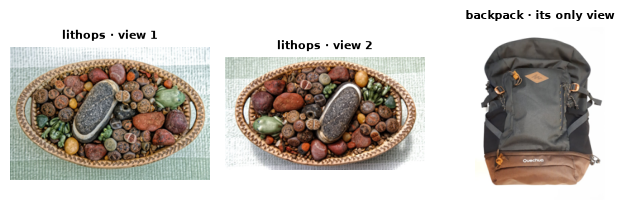

In [3]:
from helper import embed_text, show_images


def teach(shard, object_id, label, view_paths, start_id, note=None):
    vectors = embed_image(view_paths)
    note_vector = embed_text([note])[0] if note else None
    points = [
        Point(
            id=start_id + i,
            vector={"image": vectors[i],
                    **({"text": note_vector} if note else {})},
            payload={"object_id": object_id, "label": label, "view_id": i,
                     "file": view_paths[i],
                     **({"note": note} if note else {})},
        )
        for i in range(len(view_paths))
    ]
    shard.update(UpdateOperation.upsert_points(points))
    shard.optimize()


teach(object_shard, "lithops", "lithops (living stone)",
      ["../data/objects/lithops_1.jpg",
       "../data/objects/lithops_2.jpg"], start_id=0)
teach(object_shard, "backpack", "backpack",
      ["../data/objects/backpack_1.jpg"], start_id=100)
show_images(["../data/objects/lithops_1.jpg",
             "../data/objects/lithops_2.jpg",
             "../data/objects/backpack_1.jpg"],
            captions=["lithops · view 1", "lithops · view 2",
                      "backpack · its only view"])

## 4. Show it your object: not recognized yet

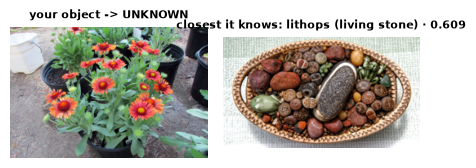

In [4]:
def recognize(shard, query_path, limit=1):
    query_vector = embed_image([query_path])[0]
    hits = shard.query(
        QueryRequest(
            query=Query.Nearest(query_vector, using="image"),
            limit=limit,
            with_payload=True,
        )
    )
    top = hits[0]
    return top, top.score >= RECOGNIZE_THRESHOLD, hits


top, known, _ = recognize(object_shard, test_photo)
verdict = top.payload["label"] if known else "UNKNOWN"
show_images([test_photo, top.payload["file"]],
            captions=[f"your object -> {verdict}",
                      f"closest it knows: {top.payload['label']}"
                      f" · {top.score:.3f}"])

## 5. Teach it, recognize it

In [5]:
teach(object_shard, "my_object", MY_LABEL, teach_photos, start_id=10)
print(f'Taught "{MY_LABEL}" from {len(teach_photos)} view(s).',
      object_shard.info().points_count, "views in memory")

Taught "orange flower" from 2 view(s). 5 views in memory


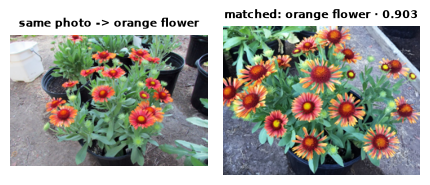

In [6]:
top, known, _ = recognize(object_shard, test_photo)
verdict = top.payload["label"] if known else "UNKNOWN"
show_images([test_photo, top.payload["file"]],
            captions=[f"same photo -> {verdict}",
                      f"matched: {top.payload['label']} · {top.score:.3f}"])

## 6. Inspect the threshold gap

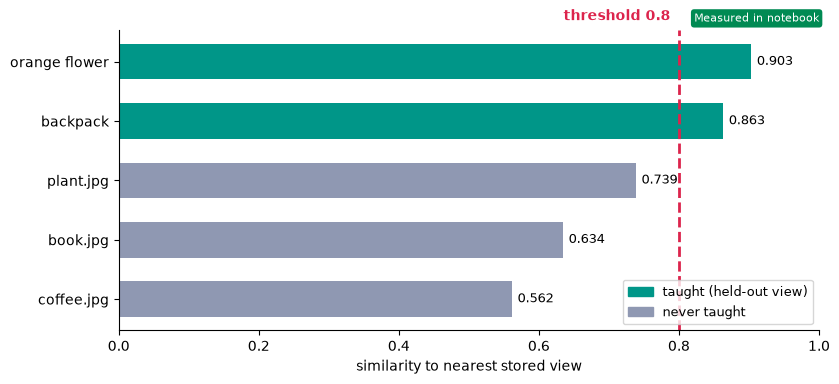

In [7]:
from helper import score_gap_chart

taught = []
for label, path in [(MY_LABEL, test_photo),
                    ("backpack", "../data/objects/backpack_2.jpg")]:
    t, _, _ = recognize(object_shard, path)
    taught.append((label, t.score))

foreign = []
for name in ["plant.jpg", "book.jpg", "coffee.jpg"]:
    t, _, _ = recognize(object_shard, f"../data/images/{name}")
    foreign.append((name, t.score))

score_gap_chart(taught, foreign, RECOGNIZE_THRESHOLD)

## 7. Assemble the assistant

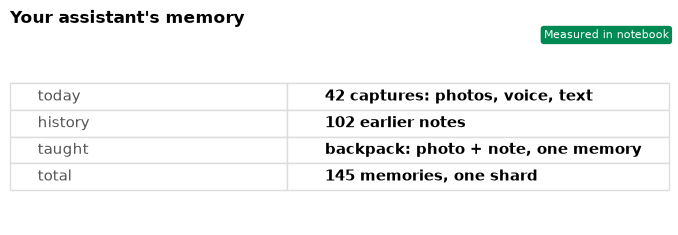

In [8]:
import json
from helper import receipt_table

ASSISTANT_DIR = fresh_start("./assistant_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
assistant_shard = EdgeShard.create(ASSISTANT_DIR, config)

day = json.load(open("../data/memories.json"))
history = json.load(open("../data/recent_days.json"))
notes = [m for m in day + history if m["source_type"] in ("text", "voice")]
photos = [m for m in day if m["source_type"] == "photo"]

text_vectors = embed_text([m.get("note") or m["transcript"] for m in notes])
assistant_shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": text_vectors[i]}, payload=m)
    for i, m in enumerate(notes)
]))
image_vectors = embed_image([f"../data/images/{m['file']}" for m in photos])
assistant_shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"image": image_vectors[i]}, payload=m)
    for i, m in enumerate(photos)
]))

teach(assistant_shard, "backpack", "backpack",
      ["../data/objects/backpack_1.jpg"], start_id=5000,
      note="Quechua daypack, bought at SportsWorld, $45")

receipt_table([
    ("today", f"{len(day)} captures: photos, voice, text"),
    ("history", f"{len(history)} earlier notes"),
    ("taught", "backpack: photo + note, one memory"),
    ("total", f"{assistant_shard.info().points_count} memories, one shard"),
], title="Your assistant's memory")

## 8. Two skills, one memory


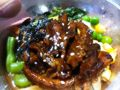

In [9]:
from helper import embed_query, embed_query_clip, memory_inbox


def recall(shard, question, limit=3):
    text_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query(question), using="text"),
            limit=limit,
            with_payload=True,
        )
    )
    image_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query_clip(question), using="image"),
            limit=limit,
            with_payload=True,
        )
    )
    return {
        "Photos": [h for h in image_hits
                   if h.payload.get("source_type") == "photo"][:1],
        "Voice Notes": [h for h in text_hits
                        if h.payload.get("source_type") == "voice"],
        "Text Notes": [h for h in text_hits
                       if h.payload.get("source_type") == "text"],
    }


hits = recall(assistant_shard, "the ramen place downtown")
memory_inbox(hits, "../data/images")

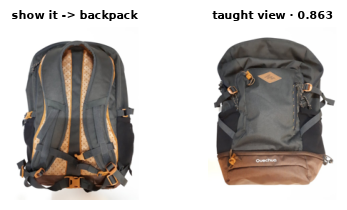

I remember this: Quechua daypack, bought at SportsWorld, $45
Asked by words  -> memory 5000: Quechua daypack, bought at SportsWorld, $45
Shown the photo -> memory 5000: backpack, score 0.863


In [10]:
top, known, _ = recognize(assistant_shard, "../data/objects/backpack_2.jpg")
verdict = top.payload["label"] if known else "UNKNOWN"
show_images(["../data/objects/backpack_2.jpg", top.payload["file"]],
            captions=[f"show it -> {verdict}",
                      f"taught view · {top.score:.3f}"])
if known:
    print("I remember this:", top.payload["note"])

# One memory, two ways in: find the same point by words.
my_question = "what did I buy at SportsWorld?"
text_hits = assistant_shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(my_question), using="text"),
        limit=1,
        with_payload=True,
    )
)
found = text_hits[0]
print(f"Asked by words  -> memory {found.id}: {found.payload['note']}")
print(f"Shown the photo -> memory {top.id}: {top.payload['label']},",
      f"score {top.score:.3f}")

## 9. It persists, and leaves the device only when you choose

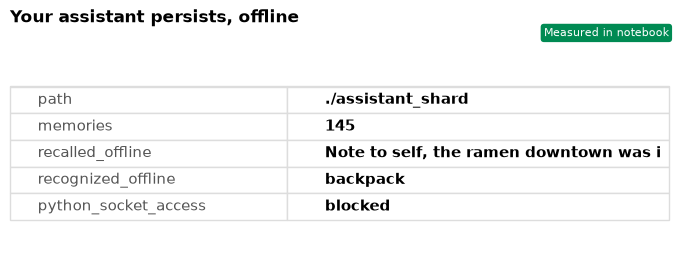

In [11]:
from helper import no_network, receipt_table

before = assistant_shard.info().points_count
assistant_shard.close()
with no_network():
    assistant_shard = EdgeShard.load(ASSISTANT_DIR)
    hits = recall(assistant_shard, "the ramen place downtown")
    top, known, _ = recognize(assistant_shard,
                              "../data/objects/backpack_2.jpg")

receipt_table([
    ("path", ASSISTANT_DIR),
    ("memories", before),
    ("recalled_offline", hits["Voice Notes"][0].payload["transcript"][:38]),
    ("recognized_offline", top.payload["label"] if known else "UNKNOWN"),
    ("python_socket_access", "blocked"),
], title="Your assistant persists, offline")

In [12]:
import os
from qdrant_edge import ScrollRequest

# Uploading is a choice you make, never a default. To send a copy to
# your own Qdrant Cloud cluster: set UPLOAD_TO_CLOUD to True and put
# the cluster's URL and API key in the QDRANT_URL and QDRANT_API_KEY
# environment variables.
UPLOAD_TO_CLOUD = False

if not (UPLOAD_TO_CLOUD and os.getenv("QDRANT_URL")
        and os.getenv("QDRANT_API_KEY")):
    print("Nothing uploaded. Every memory stays on this device.")
else:
    from qdrant_client import QdrantClient, models

    client = QdrantClient(url=os.environ["QDRANT_URL"],
                          api_key=os.environ["QDRANT_API_KEY"])
    if client.collection_exists("assistant_memory"):
        print("assistant_memory already exists on the cluster.",
              "Delete it there first, or rename the collection here.")
    else:
        records, _ = assistant_shard.scroll(
            ScrollRequest(limit=1000, with_payload=True, with_vector=True)
        )
        client.create_collection(
            "assistant_memory",
            vectors_config={
                "text": models.VectorParams(
                    size=768, distance=models.Distance.COSINE),
                "image": models.VectorParams(
                    size=512, distance=models.Distance.COSINE),
            },
        )
        client.upsert("assistant_memory", points=[
            models.PointStruct(id=r.id, vector=r.vector, payload=r.payload)
            for r in records
        ])
        print(f"Uploaded {len(records)} memories: same points, same",
              "format, readable by any Qdrant server or another device.")

Nothing uploaded. Every memory stays on this device.
